In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
data = pd.read_csv(url)


Пример использования функций для вывода информации о таблице:

`print(my_data.head()) `


In [2]:
# Вывести первые пять строк таблицы
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Вывести информацию о таблице
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Вывести описание таблицы
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Прежде чем работать с данными, необходимо заполнить пропуски

In [5]:
#Количество пропусков в каждом столбце
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Заполняем пропуски таблицы (команда .filna)
пример как выглядит:

```
my_data['Название_столбца_где_заполняем_пробелы'].filna(на_что_меняем, inplace=True)

```


inplace=True - изменения сохранятся в исходной таблице, а не в созданной копии

In [6]:
# напишите ваш код здесь для изменения пустых данных в столбцах
# (для возраста подойдет среднее, для Кабины - текст "неизвестно", для порта посадки - самое часто встречающееся (мода))

data['Age'] = data['Age'].fillna(data['Age'].mean())

data['Cabin'] = data['Cabin'].fillna('неизвестно')

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [7]:
# проверье, что теперь не осталось пробелов в данных
data.isnull().sum().sum()

np.int64(0)

Постройте первый график распределения выживших (как называется параметр отвечающий за выжившего?)

Для распределения количества (count) на графике используйте библиотеку sns.countplot(x='Название параметра из таблицы, который распределяет значения по оси х', data=data)

Используя библиотеку plt
Добавьте название графика с помощью функции .title('Название графика')
Выведите график с помощью .show()



```
#Пример
sns.countplot(x="Sex", data=data)
plt.title("Распределение пола")
plt.show()
```



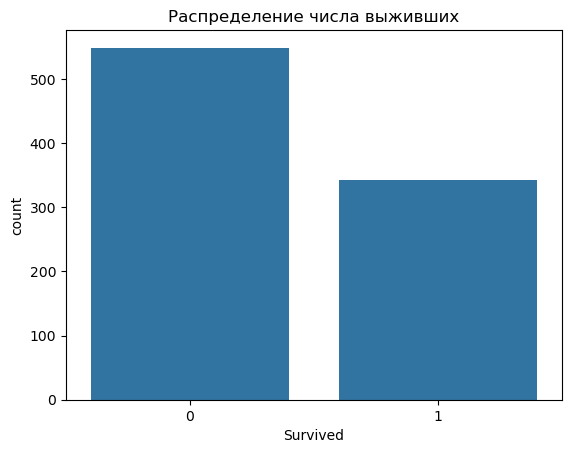

In [8]:
# напишите ваш код здесь
sns.countplot(x="Survived", data=data)
plt.title("Распределение числа выживших")
plt.show()

Теперь, когда вы получили график с общим количеством выживших давайте построим графики более интересные такие как выживаемость в зависимости от пола

Как выглядит функция countplot для графиков, где есть x и y?

countplot(x="параметры по х ваше распределение, например по полу", hue="параметры у, например выжившие", data=data)

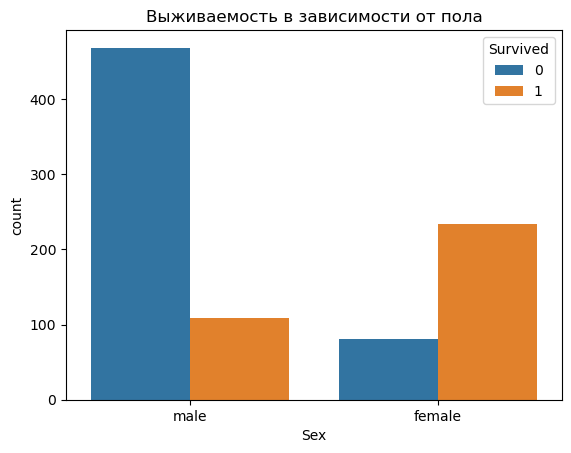

In [9]:
#Выживаемость в зависимости от пола

sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Выживаемость в зависимости от пола")
plt.show()

Постройте следующий график:





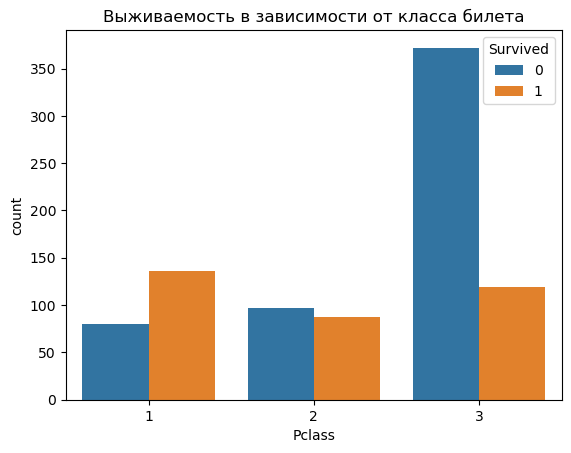

In [10]:
#Выживаемость в зависимости от класса билета

sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title("Выживаемость в зависимости от класса билета")
plt.show()

Постройте следующий график:

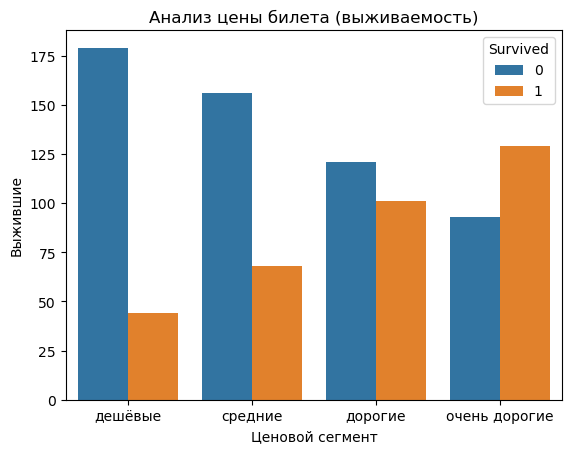

In [11]:
# напишите ваш код здесь для анализа цены билета (как она влияла на выживаемость)

data['FareGroup'] = pd.qcut(data['Fare'], q=4, labels=['дешёвые', 'средние', 'дорогие', 'очень дорогие'])

sns.countplot(x='FareGroup', hue='Survived', data=data)

plt.title("Анализ цены билета (выживаемость)")
plt.xlabel("Ценовой сегмент")
plt.ylabel("Выжившие")

plt.show()

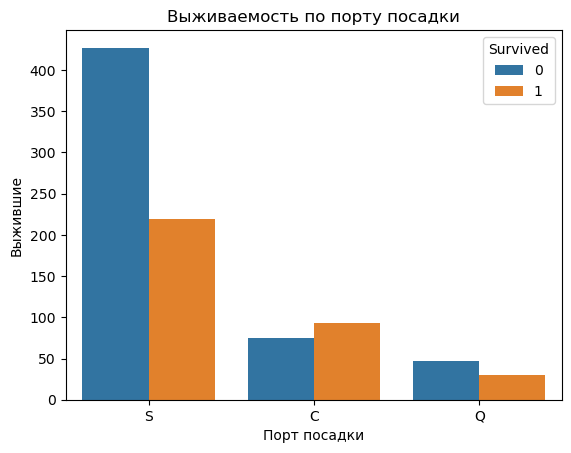

In [12]:
#Анализ посадки
# напишите код для анализа выживаемость по порту посадки

sns.countplot(x='Embarked', hue='Survived', data=data)
plt.title("Выживаемость по порту посадки")
plt.xlabel("Порт посадки")
plt.ylabel("Выжившие")
plt.show()

# Деление на группы

Очень часто так происходит, что нужных нам групп данных нет в таблице, потому что их не предусмотрели, но мы можем сами сделать новый столбец, для анализа

Пример, деление билета на группы по стоимости:


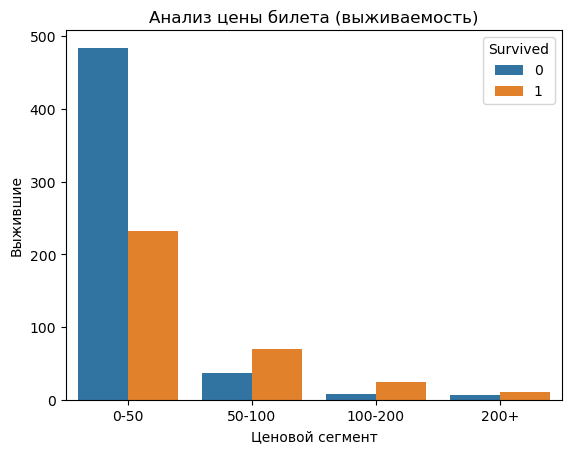

In [13]:
bins = [0, 50, 100, 200, 300] # Деление на группы
labels = ['0-50', '50-100', '100-200', '200+'] # Подписи к нашим группам

# Создание нового столбца с помощью данных цены билета,
# деление производится с помощью bins, подписи с помощью labels
data['FareGroup'] = pd.cut(data['Fare'], bins=bins, labels=labels)

sns.countplot(x='FareGroup', hue='Survived', data=data)
plt.title("Анализ цены билета (выживаемость)")
plt.xlabel("Ценовой сегмент")
plt.ylabel("Выжившие")

plt.show()

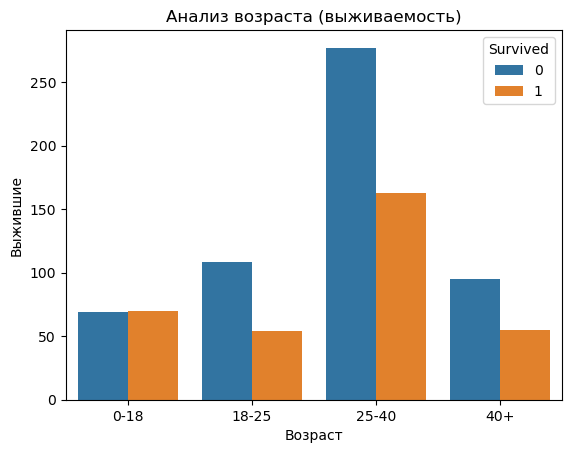

In [14]:
# Распределение выживаемости по возрасту
# Напишите ваш код здесь

bins = [0, 18, 25, 40, 80]
labels = ['0-18', '18-25', '25-40', '40+']
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels)

sns.countplot(x='AgeGroup', hue='Survived', data=data)
plt.title("Анализ возраста (выживаемость)")
plt.xlabel("Возраст")
plt.ylabel("Выжившие")

plt.show()

Создайте новый столбец размер семьи (количество детей SibSp + количество родителей Parch)

data['новый столбец'] = data['параметр'] + data['параметр']





In [15]:
# Напишите ваш код здесь

data['FamSize'] = data['SibSp'] + data['Parch']

Постройте график выживаемости в зависимости от размера семьи

Text(0, 0.5, 'Выжившие')

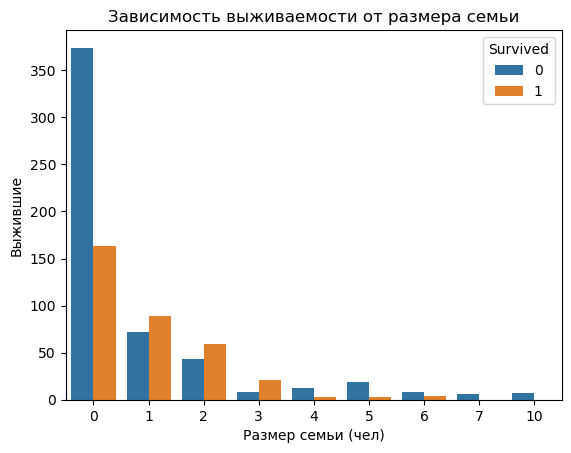

In [16]:
# График выживаемости от размера семьи

sns.countplot(x='FamSize', hue='Survived', data=data)
plt.title("Зависимость выживаемости от размера семьи")
plt.xlabel("Размер семьи (чел)")
plt.ylabel("Выжившие")

Создайте столбец одиночек

Для того чтобы написать условие при создании столбца вы должны заключить его в скобки

Пример:

#Создание столбца был ли кто-то на борту с нулевой стоимостью билета
data['OneDollar'] = (data['Fare'] == 0).astype(int)

astype(int) - для того чтобы переделать в числовой вид 0 - не был
1 - был

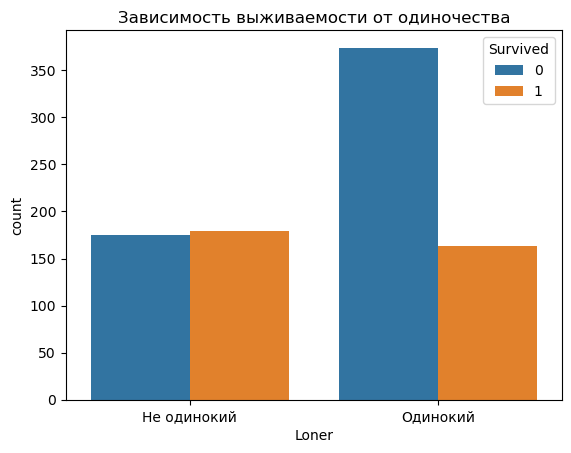

In [17]:
#Создание столбца были ли одни на борту (Проверьте количество людей в семье, чему оно должно быть равно?)

data['Loner'] = (data['FamSize'] == 0).astype(int)

# Постройте график выживаемости одиночек

sns.countplot(x='Loner', hue='Survived', data=data)
plt.title("Зависимость выживаемости от одиночества")
plt.xticks(ticks=[0, 1], labels=['Не одинокий', 'Одинокий'])
plt.show()

# Тепловая карта корреляции признаков (посмотрим от чего зависила выживаемость)

Первым делом нужно оставить только те столбцы, которые являются числами

Создайте переменную numeric_data в которую с помощью применения select_types к нашей таблице будут выбраны только столбцы с числами

Пример:


таблица_только_с_числами = таблица.select_dtypes(include=['тип', 'тип'])

include - функция для выбора только из предложенных типов

P.S. тип для целых чисел int64, тип для вещественных float64

In [18]:
# создайте таблицу только с числами

numeric_data = data.select_dtypes(include=['int64', 'float64'])

Для построения тепловой карты воспользуемся графиком heatmup c параметрами(
  наша_таблица_с_числами.corr(), # для того чтобы найти корреляцию

  annot=True, # для отображения чисел внутри корреляции
  
  cmap='coolwarm' # использование темы для оформления (градиент)
)



```
sns.heatmap(ТаблицаСЧислами.corr(), аннотация=True, тема='coolwarm')
```



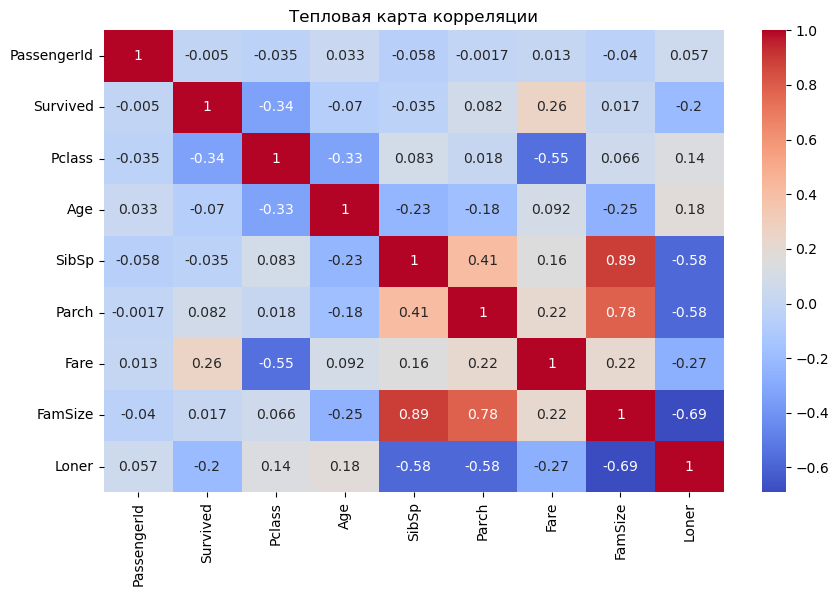

In [19]:
#тепловая карта корреляции
plt.figure(figsize=(10, 6))

# Примините график heatmap

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Тепловая карта корреляции")
plt.show()




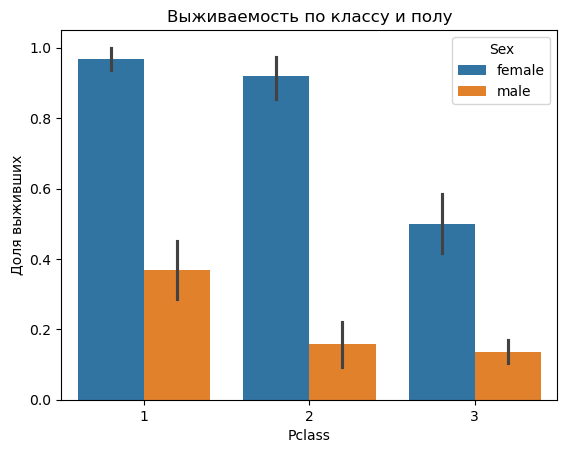

In [20]:
# Какая доля пассажиров выжила в каждом классе

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=data)
plt.title("Выживаемость по классу и полу")
plt.ylabel("Доля выживших")
plt.show()

In [21]:
data.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64